# GoldSense – Feature Engineering, Anomaly Detection & SQL Analysis

## Objective

This notebook performs feature engineering and anomaly detection on the cleaned
gold price dataset. The resulting analytical dataset is then stored in SQLite
for SQL-based analysis and visualization.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## 1. Load Cleaned Dataset

The cleaned gold price dataset produced during the data-cleaning stage is used
as the starting point for feature engineering and anomaly detection.

In [68]:
df = pd.read_csv("../data/processed/cleaned_gold.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2873, 10)

Columns:
['Date', 'Price', 'Daily_Return', 'MA_7', 'MA_30', 'Volatility_30', 'Is_Anomaly', 'Year', 'Month', 'Price_Range']

First 5 rows:


,Date,Price,Daily_Return,MA_7,MA_30,Volatility_30,Is_Anomaly,Year,Month,Price_Range
0,2011-01-01,2069,NaN,NaN,NaN,NaN,False,2011,1,1482
1,2011-01-02,2069,0.000000,NaN,NaN,NaN,False,2011,1,1482
2,2011-01-03,2076,0.338328,NaN,NaN,NaN,False,2011,1,1482
3,2011-01-04,2076,0.000000,NaN,NaN,NaN,False,2011,1,1482
4,2011-01-05,2049,-1.300578,NaN,NaN,NaN,True,2011,1,1482


In [69]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Data types:
Date              object
Price              int64
Daily_Return     float64
MA_7             float64
MA_30            float64
Volatility_30    float64
Is_Anomaly          bool
Year               int64
Month              int64
Price_Range        int64
dtype: object

Missing values:
Date              0
Price             0
Daily_Return      1
MA_7              6
MA_30            29
Volatility_30    30
Is_Anomaly        0
Year              0
Month             0
Price_Range       0
dtype: int64

Duplicate rows:
0


In [70]:
print(df.columns.tolist())

['Date', 'Price', 'Daily_Return', 'MA_7', 'MA_30', 'Volatility_30', 'Is_Anomaly', 'Year', 'Month', 'Price_Range']


In [71]:
df.describe(include="all")

,Date,Price,Daily_Return,MA_7,MA_30,Volatility_30,Is_Anomaly,Year,Month,Price_Range
count,2873,2873.000000,2872.000000,2867.000000,2844.000000,2843.000000,2873,2873.000000,2873.000000,2873.0
unique,2873,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,2011-01-01,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,2531,NaN,NaN,NaN
mean,NaN,2819.639749,0.017184,2820.146694,2821.989932,0.712749,NaN,2014.446920,6.448312,1482.0
std,NaN,256.236196,0.788716,254.129555,245.365243,0.342665,NaN,2.267777,3.412484,0.0
min,NaN,1957.000000,-8.231926,1975.714286,2009.300000,0.223005,NaN,2011.000000,1.000000,1482.0
25%,NaN,2686.000000,-0.270688,2687.000000,2690.025000,0.496725,NaN,2012.000000,4.000000,1482.0
50%,NaN,2866.000000,0.000000,2865.142857,2871.950000,0.632314,NaN,2014.000000,6.000000,1482.0
75%,NaN,2993.000000,0.279427,2995.357143,2986.150000,0.795711,NaN,2016.000000,9.000000,1482.0


In [72]:
print("\nFirst 10 dates:")
print(df["Date"].head(5))

print("\nLast 10 dates:")
print(df["Date"].tail(5))


First 10 dates:
0    2011-01-01
1    2011-01-02
2    2011-01-03
3    2011-01-04
4    2011-01-05
Name: Date, dtype: object

Last 10 dates:
2868    2018-11-12
2869    2018-11-13
2870    2018-11-14
2871    2018-11-15
2872    2018-11-16
Name: Date, dtype: object


In [73]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Date             datetime64[ns]
Price                     int64
Daily_Return            float64
MA_7                    float64
MA_30                   float64
Volatility_30           float64
Is_Anomaly                 bool
Year                      int64
Month                     int64
Price_Range               int64
dtype: object


## 1. Daily Return

Daily Return measures the percentage change in gold price from one day to the next.

It helps identify daily price movements and short-term changes in the gold market.

In [74]:
# Daily Return
df["Daily_Return"] = df["Price"].pct_change() * 100

print(df[["Date", "Price", "Daily_Return"]].head(10))

        Date  Price  Daily_Return
0 2011-01-01   2069           NaN
1 2011-01-02   2069      0.000000
2 2011-01-03   2076      0.338328
3 2011-01-04   2076      0.000000
4 2011-01-05   2049     -1.300578
5 2011-01-06   2043     -0.292826
6 2011-01-07   2035     -0.391581
7 2011-01-08   2024     -0.540541
8 2011-01-09   2024      0.000000
9 2011-01-10   2045      1.037549


## 2. 7-Day Moving Average

The 7-Day Moving Average calculates the average gold price over the previous 7 days.

It smooths out daily fluctuations and helps identify the short-term price trend.

In [75]:
# 7-Day Moving Average
df["MA_7"] = df["Price"].rolling(window=7).mean()

print(df[["Date", "Price", "MA_7"]].head(15))

         Date  Price         MA_7
0  2011-01-01   2069          NaN
1  2011-01-02   2069          NaN
2  2011-01-03   2076          NaN
3  2011-01-04   2076          NaN
4  2011-01-05   2049          NaN
5  2011-01-06   2043          NaN
6  2011-01-07   2035  2059.571429
7  2011-01-08   2024  2053.142857
8  2011-01-09   2024  2046.714286
9  2011-01-10   2045  2042.285714
10 2011-01-11   2042  2037.428571
11 2011-01-12   2047  2037.142857
12 2011-01-13   2045  2037.428571
13 2011-01-14   2039  2038.000000
14 2011-01-15   2031  2039.000000


## 3. 30-Day Moving Average

The 30-Day Moving Average calculates the average gold price over the previous 30 days.

It helps identify the medium-term trend in gold prices and reduces the effect of short-term daily fluctuations.

In [76]:
# 30-Day Moving Average
df["MA_30"] = df["Price"].rolling(window=30).mean()

print(df[["Date", "Price", "MA_30"]].head(35))

         Date  Price        MA_30
0  2011-01-01   2069          NaN
1  2011-01-02   2069          NaN
2  2011-01-03   2076          NaN
3  2011-01-04   2076          NaN
4  2011-01-05   2049          NaN
5  2011-01-06   2043          NaN
6  2011-01-07   2035          NaN
7  2011-01-08   2024          NaN
8  2011-01-09   2024          NaN
9  2011-01-10   2045          NaN
10 2011-01-11   2042          NaN
11 2011-01-12   2047          NaN
12 2011-01-13   2045          NaN
13 2011-01-14   2039          NaN
14 2011-01-15   2031          NaN
15 2011-01-16   2031          NaN
16 2011-01-17   2029          NaN
17 2011-01-18   2033          NaN
18 2011-01-19   2037          NaN
19 2011-01-20   2036          NaN
20 2011-01-21   2011          NaN
21 2011-01-22   2006          NaN
22 2011-01-23   2006          NaN
23 2011-01-24   2012          NaN
24 2011-01-25   1982          NaN
25 2011-01-26   1991          NaN
26 2011-01-27   1996          NaN
27 2011-01-28   1957          NaN
28 2011-01-29 

## 4. 30-Day Rolling Volatility

30-Day Rolling Volatility measures the variation in daily gold returns over the previous 30 days.

It helps identify periods of higher or lower price instability in the gold market.

In [77]:
# 30-Day Rolling Volatility
df["Volatility_30"] = df["Daily_Return"].rolling(window=30).std()

print(df[["Date", "Daily_Return", "Volatility_30"]].head(40))

         Date  Daily_Return  Volatility_30
0  2011-01-01           NaN            NaN
1  2011-01-02      0.000000            NaN
2  2011-01-03      0.338328            NaN
3  2011-01-04      0.000000            NaN
4  2011-01-05     -1.300578            NaN
5  2011-01-06     -0.292826            NaN
6  2011-01-07     -0.391581            NaN
7  2011-01-08     -0.540541            NaN
8  2011-01-09      0.000000            NaN
9  2011-01-10      1.037549            NaN
10 2011-01-11     -0.146699            NaN
11 2011-01-12      0.244858            NaN
12 2011-01-13     -0.097704            NaN
13 2011-01-14     -0.293399            NaN
14 2011-01-15     -0.392349            NaN
15 2011-01-16      0.000000            NaN
16 2011-01-17     -0.098474            NaN
17 2011-01-18      0.197141            NaN
18 2011-01-19      0.196754            NaN
19 2011-01-20     -0.049092            NaN
20 2011-01-21     -1.227898            NaN
21 2011-01-22     -0.248633            NaN
22 2011-01-

## 5. 7-Day Momentum

7-Day Momentum measures the difference between the current gold price and its price 7 days earlier.

A positive value indicates an upward price movement, while a negative value indicates a downward movement.

In [78]:
# 7-Day Momentum
df["Momentum_7"] = df["Price"] - df["Price"].shift(7)

print(df[["Date", "Price", "Momentum_7"]].head(15))

         Date  Price  Momentum_7
0  2011-01-01   2069         NaN
1  2011-01-02   2069         NaN
2  2011-01-03   2076         NaN
3  2011-01-04   2076         NaN
4  2011-01-05   2049         NaN
5  2011-01-06   2043         NaN
6  2011-01-07   2035         NaN
7  2011-01-08   2024       -45.0
8  2011-01-09   2024       -45.0
9  2011-01-10   2045       -31.0
10 2011-01-11   2042       -34.0
11 2011-01-12   2047        -2.0
12 2011-01-13   2045         2.0
13 2011-01-14   2039         4.0
14 2011-01-15   2031         7.0


## 6. Lag Features

Lag features represent historical gold prices from previous periods.

- Price_Lag_1: Gold price from 1 day earlier
- Price_Lag_7: Gold price from 7 days earlier
- Price_Lag_30: Gold price from 30 days earlier

These features help compare the current price with recent and longer-term historical prices.

In [79]:
# Lag Features
df["Price_Lag_1"] = df["Price"].shift(1)
df["Price_Lag_7"] = df["Price"].shift(7)
df["Price_Lag_30"] = df["Price"].shift(30)

print(df[[
    "Date",
    "Price",
    "Price_Lag_1",
    "Price_Lag_7",
    "Price_Lag_30"
]].head(10)) 

        Date  Price  Price_Lag_1  Price_Lag_7  Price_Lag_30
0 2011-01-01   2069          NaN          NaN           NaN
1 2011-01-02   2069       2069.0          NaN           NaN
2 2011-01-03   2076       2069.0          NaN           NaN
3 2011-01-04   2076       2076.0          NaN           NaN
4 2011-01-05   2049       2076.0          NaN           NaN
5 2011-01-06   2043       2049.0          NaN           NaN
6 2011-01-07   2035       2043.0          NaN           NaN
7 2011-01-08   2024       2035.0       2069.0           NaN
8 2011-01-09   2024       2024.0       2069.0           NaN
9 2011-01-10   2045       2024.0       2076.0           NaN


## 7. Price vs 30-Day Moving Average

This feature measures the difference between the current gold price and its 30-day moving average.

A positive value indicates that the current price is above its medium-term average, while a negative value indicates that it is below the average.

In [80]:
# Price Difference from 30-Day Moving Average
df["Price_vs_MA30"] = df["Price"] - df["MA_30"]

print(df[[
    "Date",
    "Price",
    "MA_30",
    "Price_vs_MA30"
]].head(35))

         Date  Price        MA_30  Price_vs_MA30
0  2011-01-01   2069          NaN            NaN
1  2011-01-02   2069          NaN            NaN
2  2011-01-03   2076          NaN            NaN
3  2011-01-04   2076          NaN            NaN
4  2011-01-05   2049          NaN            NaN
5  2011-01-06   2043          NaN            NaN
6  2011-01-07   2035          NaN            NaN
7  2011-01-08   2024          NaN            NaN
8  2011-01-09   2024          NaN            NaN
9  2011-01-10   2045          NaN            NaN
10 2011-01-11   2042          NaN            NaN
11 2011-01-12   2047          NaN            NaN
12 2011-01-13   2045          NaN            NaN
13 2011-01-14   2039          NaN            NaN
14 2011-01-15   2031          NaN            NaN
15 2011-01-16   2031          NaN            NaN
16 2011-01-17   2029          NaN            NaN
17 2011-01-18   2033          NaN            NaN
18 2011-01-19   2037          NaN            NaN
19 2011-01-20   2036

## 8. 90-Day Moving Average

The 90-Day Moving Average calculates the average gold price over the previous 90 days.

It helps identify the longer-term trend in gold prices and provides a smoother view of price movements compared with shorter moving averages.

In [81]:
# 90-Day Moving Average
df["MA_90"] = df["Price"].rolling(window=90).mean()

print(df[[
    "Date",
    "Price",
    "MA_7",
    "MA_30",
    "MA_90"
]].head(100))

         Date  Price         MA_7        MA_30        MA_90
0  2011-01-01   2069          NaN          NaN          NaN
1  2011-01-02   2069          NaN          NaN          NaN
2  2011-01-03   2076          NaN          NaN          NaN
3  2011-01-04   2076          NaN          NaN          NaN
4  2011-01-05   2049          NaN          NaN          NaN
..        ...    ...          ...          ...          ...
95 2011-04-06   2117  2081.428571  2085.466667  2053.855556
96 2011-04-07   2117  2087.714286  2085.933333  2054.766667
97 2011-04-08   2122  2095.428571  2086.633333  2055.855556
98 2011-04-09   2130  2104.000000  2087.366667  2057.033333
99 2011-04-10   2130  2112.571429  2088.700000  2057.977778

[100 rows x 5 columns]


## 9. Final Feature Engineering Check

The final dataset is reviewed to verify that all engineered features have been created correctly before saving the feature-engineered dataset.

In [82]:
# Final feature list
print("Final columns:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Final columns:
['Date', 'Price', 'Daily_Return', 'MA_7', 'MA_30', 'Volatility_30', 'Is_Anomaly', 'Year', 'Month', 'Price_Range', 'Momentum_7', 'Price_Lag_1', 'Price_Lag_7', 'Price_Lag_30', 'Price_vs_MA30', 'MA_90']

Dataset shape: (2873, 16)

Missing values:
Date              0
Price             0
Daily_Return      1
MA_7              6
MA_30            29
Volatility_30    30
Is_Anomaly        0
Year              0
Month             0
Price_Range       0
Momentum_7        7
Price_Lag_1       1
Price_Lag_7       7
Price_Lag_30     30
Price_vs_MA30    29
MA_90            89
dtype: int64


## 10. Save Feature-Engineered Dataset

The feature-engineered dataset is saved as a separate CSV file so that the newly created analytical features can be used for further SQL analysis and anomaly detection.

In [83]:
# Save feature-engineered dataset
df.to_csv("../data/processed/feature_engineered_gold.csv", index=False)

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.


## Anomaly Analysis

This section identifies how many observations in the gold price dataset were classified as anomalies and how many were considered normal.

In [84]:
# Anomaly Analysis

print("Total anomalies:", df["Is_Anomaly"].sum())
print("Total normal observations:", (~df["Is_Anomaly"]).sum())

Total anomalies: 342
Total normal observations: 2531


## Identifying Anomalous Observations

This section extracts the observations classified as anomalies so that their dates, prices, and related features can be examined.

In [85]:
anomalies = df[df["Is_Anomaly"] == True]

print("Number of anomalies:", len(anomalies))
display(anomalies[["Date", "Price", "Daily_Return", "Volatility_30"]].head(20))

Number of anomalies: 342


,Date,Price,Daily_Return,Volatility_30
4,2011-01-05,2049,-1.300578,NaN
20,2011-01-21,2011,-1.227898,NaN
24,2011-01-25,1982,-1.491054,NaN
27,2011-01-28,1957,-1.953908,NaN
30,2011-01-31,1998,1.886792,0.719599
34,2011-02-04,2006,1.415571,0.739817
58,2011-02-28,2110,1.199041,0.573813
65,2011-03-07,2124,1.724138,0.548175
74,2011-03-16,2064,-1.338432,0.648396
94,2011-04-05,2103,1.643306,0.651721


## Anomaly Price Statistics

This section compares the price statistics of anomalous observations to understand their price range and overall behavior.

In [86]:
print("Anomalous Price Statistics:")
print(anomalies["Price"].describe())

Anomalous Price Statistics:
count     342.000000
mean     2795.526316
std       255.296408
min      1957.000000
25%      2666.250000
50%      2813.500000
75%      2967.750000
max      3439.000000
Name: Price, dtype: float64


## Anomaly Return Analysis

This section examines the daily returns of anomalous observations to understand the magnitude of their price movements.

In [87]:
print("Anomalous Daily Return Statistics:")
print(anomalies["Daily_Return"].describe())

Anomalous Daily Return Statistics:
count    342.000000
mean       0.174559
std        1.976150
min       -8.231926
25%       -1.441371
50%        1.179070
75%        1.571136
max        5.806654
Name: Daily_Return, dtype: float64


## Extreme Anomalous Price Movements

This section identifies the observations with the largest positive and negative daily returns among the detected anomalies.

In [88]:
print("Largest Positive Anomalies:")
display(
    anomalies.nlargest(10, "Daily_Return")
    [["Date", "Price", "Daily_Return", "Volatility_30"]]
)

print("\nLargest Negative Anomalies:")
display(
    anomalies.nsmallest(10, "Daily_Return")
    [["Date", "Price", "Daily_Return", "Volatility_30"]]
)

Largest Positive Anomalies:


,Date,Price,Daily_Return,Volatility_30
965,2013-08-27,3371,5.806654,1.815737
954,2013-08-16,3072,5.385935,1.525588
1863,2016-02-11,2951,4.943101,1.086973
1997,2016-06-24,3129,4.439252,1.207847
238,2011-08-27,2768,4.216867,1.797004
972,2013-09-03,3439,4.054463,1.906376
230,2011-08-19,2753,3.691149,1.171492
950,2013-08-12,2886,3.440860,1.239309
219,2011-08-08,2510,3.292181,0.926757
1434,2014-12-09,2721,3.263757,0.951922



Largest Negative Anomalies:


,Date,Price,Daily_Return,Volatility_30
831,2013-04-15,2564,-8.231926,1.758578
265,2011-09-23,2629,-5.804371,2.117571
973,2013-09-04,3260,-5.205001,2.129943
236,2011-08-25,2601,-5.003652,1.643679
1065,2013-12-05,2925,-4.908973,1.150726
249,2011-09-07,2749,-4.282730,2.022117
268,2011-09-26,2569,-3.926702,1.855806
897,2013-06-20,2697,-3.712960,1.070803
828,2013-04-12,2819,-3.425831,0.953705
424,2012-02-29,2798,-3.250346,0.842461


## Gold Price Trend and Anomalies

This visualization shows the movement of gold prices over time and highlights
the observations identified as anomalies. This helps identify periods where
unusual market movements occurred.

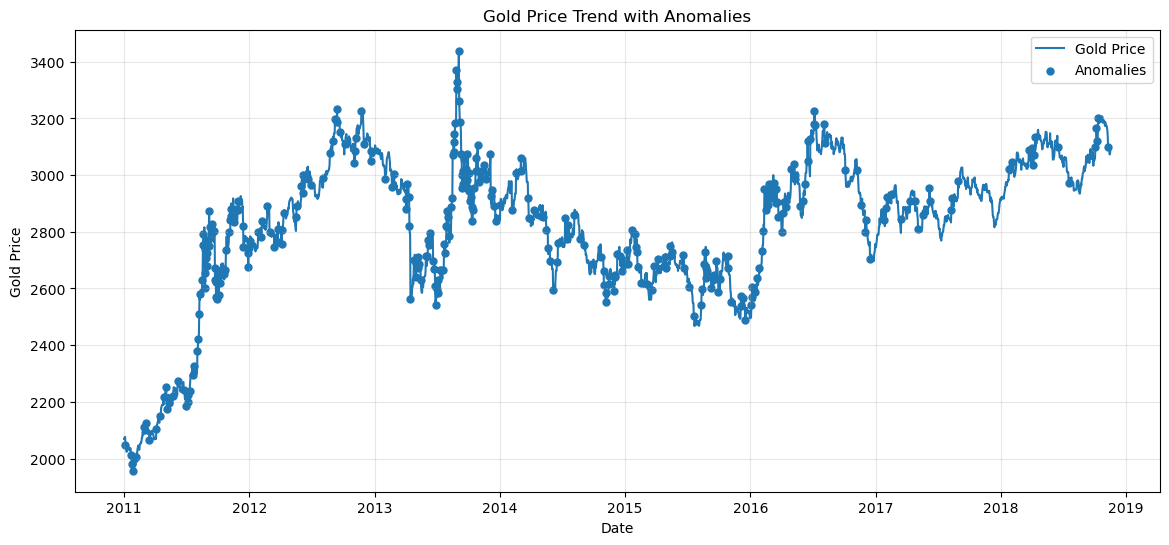

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Normal price trend
plt.plot(df["Date"], df["Price"], label="Gold Price")

# Highlight anomalies
anomalies = df[df["Is_Anomaly"] == True]

plt.scatter(
    anomalies["Date"],
    anomalies["Price"],
    label="Anomalies",
    s=25
)

plt.title("Gold Price Trend with Anomalies")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [90]:
import sqlite3
import pandas as pd

# Load the final feature-engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_gold.csv")

# Create a new SQLite database
conn = sqlite3.connect("../notebooks/goldsense.db")

# Store the dataset as a SQL table
df.to_sql("gold_prices", conn, if_exists="replace", index=False)

print("Database created successfully!")
print("Table: gold_prices")
print("Rows:", len(df))

Database created successfully!
Table: gold_prices
Rows: 2873


## SQL Analysis 1 — Overall Gold Price Summary

This query provides a high-level summary of the complete gold price dataset.
It shows the total number of observations along with the minimum, maximum,
and average gold price.

These values help us understand the overall price range and central price
level during the entire study period.

In [91]:
import pandas as pd
query = """
SELECT 
    COUNT(*) AS total_records,
    MIN(Price) AS minimum_price,
    MAX(Price) AS maximum_price,
    ROUND(AVG(Price), 2) AS average_price
FROM gold_prices;
"""

result = pd.read_sql_query(query, conn)
display(result)

,total_records,minimum_price,maximum_price,average_price
0,2873,1957,3439,2819.64


## SQL Analysis 2 — Year-wise Gold Price Analysis

This query compares gold prices across different years.

For each year, we calculate the number of available trading days,
average price, minimum price, and maximum price.

This helps us understand how the gold price level changed over time
and which years experienced relatively higher or lower prices.

In [92]:
query = """
SELECT
    Year,
    COUNT(*) AS total_days,
    ROUND(AVG(Price), 2) AS average_price,
    MIN(Price) AS minimum_price,
    MAX(Price) AS maximum_price
FROM gold_prices
GROUP BY Year
ORDER BY Year;
"""

result = pd.read_sql_query(query, conn)
display(result)                                                                                                                     

,Year,total_days,average_price,minimum_price,maximum_price
0,2011,365,2395.58,1957,2926
1,2012,366,2968.84,2731,3235
2,2013,361,2899.26,2540,3439
3,2014,365,2792.36,2548,3061
4,2015,365,2634.41,2468,2805
5,2016,366,2943.86,2497,3225
6,2017,365,2892.80,2745,3027
7,2018,320,3059.72,2912,3209


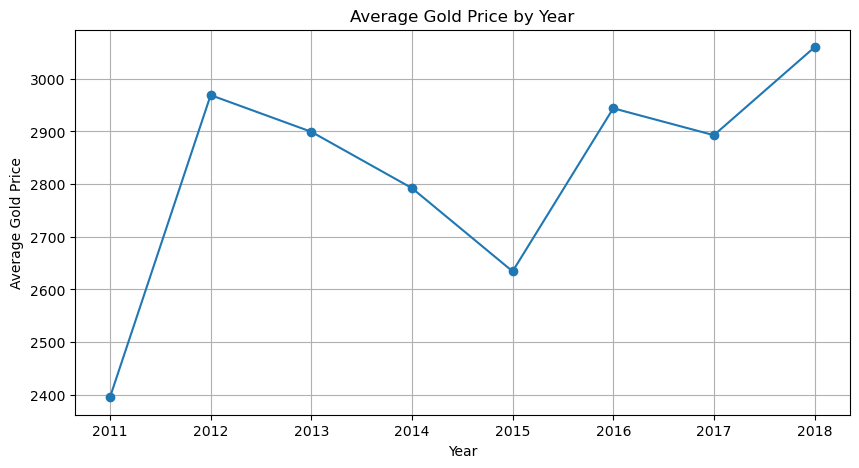

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(result["Year"], result["average_price"], marker="o")

plt.title("Average Gold Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Gold Price")
plt.xticks(result["Year"])
plt.grid(True)

plt.show()

### Interpretation

The yearly analysis shows that the average gold price did not remain constant.
The average price was lowest in 2011 and generally increased over the study
period, reaching its highest level in 2018.

This indicates an overall upward movement in the gold price across the dataset,
although the trend was not continuous every year.

## SQL Analysis 3 — Highest Gold Price Days

This query identifies the dates when gold recorded its highest prices.

Looking at the highest-price observations helps us identify periods when
gold reached unusually high levels and provides useful information for
understanding major price peaks in the dataset.

In [94]:
query = """
SELECT
    Date,
    Price
FROM gold_prices
ORDER BY Price DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Date,Price
0,2013-09-03,3439
1,2013-08-27,3371
2,2013-08-29,3360
3,2013-08-28,3329
4,2013-09-02,3305
5,2013-08-30,3303
6,2013-08-31,3298
7,2013-09-01,3298
8,2013-09-04,3260
9,2012-11-26,3235


## SQL Analysis 4 — Highest Gold Price Observations

This query identifies the 10 dates on which gold recorded its highest prices.

It helps us identify the major price peaks in the dataset and understand
when gold reached its highest observed levels.

In [95]:
query = """
SELECT
    Date,
    Price
FROM gold_prices
ORDER BY Price DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Date,Price
0,2013-09-03,3439
1,2013-08-27,3371
2,2013-08-29,3360
3,2013-08-28,3329
4,2013-09-02,3305
5,2013-08-30,3303
6,2013-08-31,3298
7,2013-09-01,3298
8,2013-09-04,3260
9,2012-11-26,3235


## SQL Analysis 5 — Year with Highest Average Gold Price

This query identifies the year in which the average gold price was the highest.

Instead of looking at individual daily prices, we compare the average price
for each year and return the year with the highest average.

This helps us identify the period with the highest overall price level.

In [96]:
query = """
SELECT
    Year,
    ROUND(AVG(Price), 2) AS average_price
FROM gold_prices
GROUP BY Year
ORDER BY average_price DESC
LIMIT 1;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,average_price
0,2018,3059.72


## SQL Analysis 6 — Highest and Lowest Average Price Year

This query compares the average gold price across all years and identifies
both the year with the highest average price and the year with the lowest
average price.

This allows us to understand the difference between the highest and lowest
overall yearly price levels.

In [97]:
query = """
SELECT
    MAX(average_price) AS highest_average_price,
    MIN(average_price) AS lowest_average_price
FROM (
    SELECT
        Year,
        AVG(Price) AS average_price
    FROM gold_prices
    GROUP BY Year
);
"""

result = pd.read_sql_query(query, conn)
display(result)

,highest_average_price,lowest_average_price
0,3059.721875,2395.575342


In [98]:
query = """
SELECT
    Year,
    ROUND(AVG(Price), 2) AS average_price
FROM gold_prices
GROUP BY Year
ORDER BY average_price DESC;
"""

result = pd.read_sql_query(query, conn)

print("Highest average price year:")
display(result.head(1))

print("Lowest average price year:")
display(result.tail(1))

Highest average price year:


,Year,average_price
0,2018,3059.72


Lowest average price year:


,Year,average_price
7,2011,2395.58


## SQL Analysis 7 — Year-wise Price Range

This query calculates the price range for each year by subtracting the
minimum gold price from the maximum gold price.

It helps us understand how much the gold price varied within each year.
A larger price range indicates greater variation between the lowest and
highest observed prices during that year.

In [99]:
query = """
SELECT
    Year,
    MIN(Price) AS minimum_price,
    MAX(Price) AS maximum_price,
    MAX(Price) - MIN(Price) AS price_range
FROM gold_prices
GROUP BY Year
ORDER BY Year;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,minimum_price,maximum_price,price_range
0,2011,1957,2926,969
1,2012,2731,3235,504
2,2013,2540,3439,899
3,2014,2548,3061,513
4,2015,2468,2805,337
5,2016,2497,3225,728
6,2017,2745,3027,282
7,2018,2912,3209,297


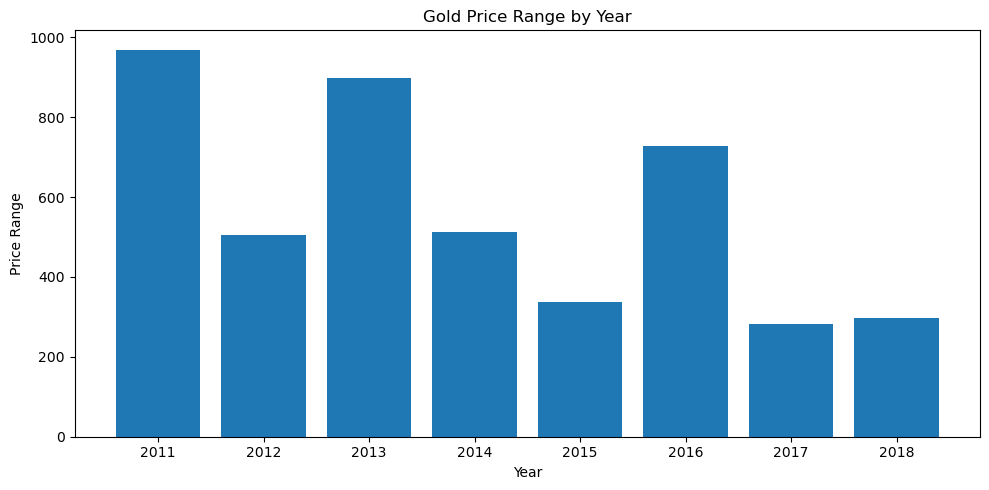

In [100]:
plt.figure(figsize=(10, 5))

plt.bar(
    result["Year"].astype(str),
    result["price_range"]
)

plt.title("Gold Price Range by Year")
plt.xlabel("Year")
plt.ylabel("Price Range")

plt.tight_layout()
plt.show()

## 8. Average Gold Price by Month

This query calculates the average gold price for each month across all available years.

It helps us understand whether there are noticeable monthly patterns in gold prices.

In [101]:
query = """
SELECT 
    Month,
    COUNT(*) AS total_days,
    ROUND(AVG(Price), 2) AS average_price,
    MIN(Price) AS minimum_price,
    MAX(Price) AS maximum_price
FROM gold_prices
GROUP BY Month
ORDER BY Month;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Month,total_days,average_price,minimum_price,maximum_price
0,1,248,2738.72,1957,3105
1,2,222,2788.22,1978,3081
2,3,248,2782.85,2058,3093
3,4,240,2777.86,2068,3160
4,5,248,2773.98,2170,3153
5,6,240,2788.95,2209,3159
6,7,248,2774.62,2173,3225
7,8,248,2882.06,2300,3371
8,9,240,2934.40,2564,3439
9,10,248,2904.12,2578,3209


## 9. Number of Records by Year

This query counts the number of gold price observations recorded for each year.

It helps us understand how much data is available for each year and whether some years contain fewer observations than others.

## 9. Year-over-Year Gold Price Change

This analysis compares the average gold price of each year with the previous year.

The percentage change helps us identify years in which gold prices increased or decreased significantly.

This provides a clearer view of the long-term price trend rather than only looking at individual daily prices.

In [102]:
query = """
WITH yearly_prices AS (
    SELECT
        Year,
        ROUND(AVG(Price), 2) AS average_price
    FROM gold_prices
    GROUP BY Year
)

SELECT
    Year,
    average_price,
    LAG(average_price) OVER (ORDER BY Year) AS previous_year_price,
    ROUND(
        (average_price - LAG(average_price) OVER (ORDER BY Year))
        * 100.0
        / LAG(average_price) OVER (ORDER BY Year),
        2
    ) AS yoy_change_percent
FROM yearly_prices
ORDER BY Year;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,average_price,previous_year_price,yoy_change_percent
0,2011,2395.58,NaN,NaN
1,2012,2968.84,2395.58,23.93
2,2013,2899.26,2968.84,-2.34
3,2014,2792.36,2899.26,-3.69
4,2015,2634.41,2792.36,-5.66
5,2016,2943.86,2634.41,11.75
6,2017,2892.80,2943.86,-1.73
7,2018,3059.72,2892.80,5.77


## 10. Best and Worst Yearly Price Performance

This analysis identifies the years with the highest and lowest year-over-year changes in average gold price.

It helps us understand which years experienced the strongest increase or decrease in gold prices compared with the previous year.

In [103]:
query = """
WITH yearly_prices AS (
    SELECT
        Year,
        AVG(Price) AS average_price
    FROM gold_prices
    GROUP BY Year
),

yearly_change AS (
    SELECT
        Year,
        ROUND(average_price, 2) AS average_price,
        ROUND(
            (average_price - LAG(average_price) OVER (ORDER BY Year))
            * 100.0
            / LAG(average_price) OVER (ORDER BY Year),
            2
        ) AS yoy_change_percent
    FROM yearly_prices
)

SELECT
    Year,
    average_price,
    yoy_change_percent
FROM yearly_change
WHERE yoy_change_percent IS NOT NULL
ORDER BY yoy_change_percent DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,average_price,yoy_change_percent
0,2012,2968.84,23.93
1,2016,2943.86,11.75
2,2018,3059.72,5.77
3,2017,2892.80,-1.73
4,2013,2899.26,-2.34
5,2014,2792.36,-3.69
6,2015,2634.41,-5.66


## 11. Price and Volatility Analysis

This analysis compares the average gold price with the average 30-day volatility for each year.

It helps us understand whether periods with higher gold prices were also associated with greater price fluctuations and market uncertainty.

In [104]:
query = """
SELECT
    Year,
    ROUND(AVG(Price), 2) AS average_price,
    ROUND(AVG(Volatility_30), 3) AS average_volatility
FROM gold_prices
GROUP BY Year
ORDER BY Year;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,average_price,average_volatility
0,2011,2395.58,0.940
1,2012,2968.84,0.598
2,2013,2899.26,1.093
3,2014,2792.36,0.706
4,2015,2634.41,0.670
5,2016,2943.86,0.743
6,2017,2892.80,0.480
7,2018,3059.72,0.463


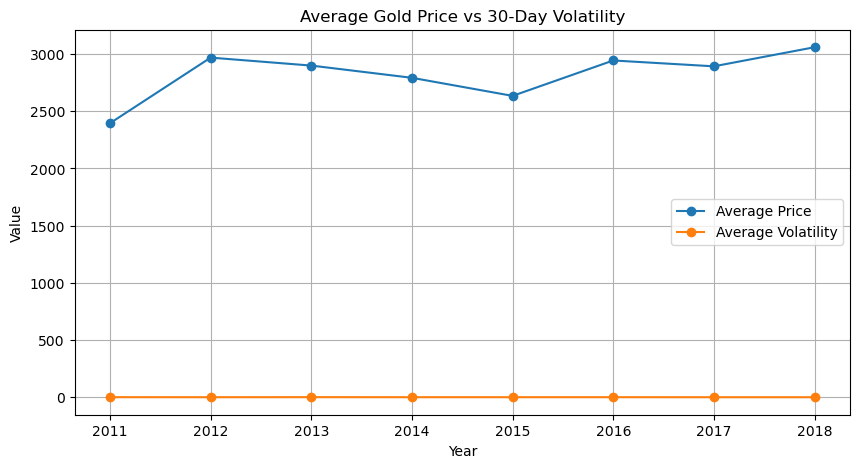

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(result["Year"], result["average_price"], marker="o", label="Average Price")
plt.plot(result["Year"], result["average_volatility"], marker="o", label="Average Volatility")

plt.title("Average Gold Price vs 30-Day Volatility")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

## 12. Identifying High-Volatility Periods

This analysis identifies the observations with the highest 30-day volatility.

It helps us locate periods of increased price instability and market risk, which can be compared with the anomalies identified during the Python analysis.

In [106]:
query = """
SELECT
    Date,
    Price,
    Daily_Return,
    Volatility_30
FROM gold_prices
WHERE Volatility_30 IS NOT NULL
ORDER BY Volatility_30 DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Date,Price,Daily_Return,Volatility_30
0,2013-09-14,3014,2.031144,2.248143
1,2013-09-10,3074,-2.567353,2.239651
2,2013-09-13,2954,-1.533333,2.220024
3,2013-09-12,3000,-2.184545,2.208031
4,2013-09-09,3155,-0.973007,2.172468
5,2013-09-11,3067,-0.227716,2.163805
6,2013-09-07,3186,-0.031377,2.158517
7,2013-09-08,3186,0.000000,2.158241
8,2013-09-06,3187,-1.178295,2.158126
9,2013-09-05,3225,-1.073620,2.135924


## Key Findings

- The dataset contains 2,873 daily observations covering 2011–2018.
- Gold prices ranged from 1,957 to 3,439 during the study period.
- The overall average gold price was approximately 2,819.64.
- 342 observations were identified as anomalies, while 2,531 observations were classified as normal.
- 2012 recorded the highest year-over-year increase in average gold price at 23.93%.
- 2015 recorded the largest year-over-year decline at 5.66%.
- 2018 had the highest average annual gold price at approximately 3,059.72.
- September had the highest average monthly gold price at approximately 2,934.40.
- Several anomalous observations were associated with unusually large positive or negative daily returns.
- High-volatility periods were identified using the 30-day rolling volatility feature.

## Conclusion

The GoldSense project demonstrates how historical gold price data can be transformed into meaningful analytical insights using Python, feature engineering, anomaly detection and SQL.

The analysis reveals significant variation in gold prices across years and months, along with periods of unusually large daily price movements and increased volatility.

Feature engineering provided additional information about short-term trends, momentum, previous prices and rolling behaviour, while anomaly detection helped identify observations that differed significantly from normal price movements.

SQL analysis further supported the investigation by summarizing yearly and monthly trends, year-over-year changes and high-volatility periods.

The final dashboard brings these findings together into a visual format that allows users to explore gold price trends, performance, volatility and anomalous observations.